# Análise de Consumo Energético — PPH 2019

Este notebook transforma o banco de dados bruto da pesquisa **PPH 2019** (três abas:
`Banco de Dados`, `Texto das perguntas`, `Texto das alternativas`) em uma tabela única,
com **uma linha por entrevista** e **uma coluna por informação relevante**, cobrindo:

- **Quantidade** de 11 aparelhos selecionados;
- **Consumo elétrico estimado** (kWh/mês) de cada aparelho;
- **Consumo agregado por categoria** (Iluminação, Refrigeração, Climatização,
  Eletrodomésticos, Tecnologia);
- **Consumo real declarado** (histórico da conta de luz) e **fonte de energia**;
- **Hábitos de economia de energia** ligados aos aparelhos escolhidos;
- Um **ranking** dos aparelhos e categorias que mais consomem energia.

## Aparelhos selecionados

| Categoria | Aparelhos |
|---|---|
| Iluminação | Lâmpadas |
| Refrigeração | Geladeira |
| Climatização | Ventilador, Ar-condicionado |
| Eletrodomésticos | Micro-ondas, Air Fryer, Máquina de lavar/Secadora, Chuveiro Elétrico |
| Tecnologia | Computadores, Videogame, TV |

## Como este notebook está organizado

1. Configuração e carregamento dos dados
2. Construção do "codebook" (dicionários de perguntas e respostas)
3. Funções utilitárias de decodificação (frequência, duração, potência)
4. Cálculo do consumo estimado, aparelho por aparelho
5. Consolidação da tabela final
6. Rankings (top aparelhos, top categoria, coluna de maior consumo)
7. Exportação dos arquivos `.csv`

> **Sobre as estimativas de consumo:** a pesquisa não mede o consumo elétrico de cada
> aparelho diretamente (só existe medição direta para o **chuveiro elétrico**, via
> potência declarada, e indiretamente para o **ar-condicionado**, via capacidade em
> BTU/h). Para os demais aparelhos, o consumo é **estimado** a partir de:
> `quantidade × potência típica (W) × horas de uso × dias de uso no mês`.
> Todas as potências assumidas estão documentadas e reunidas em um único lugar
> (Seção 3), para que você possa ajustá-las facilmente caso tenha valores mais
> precisos (ex.: etiqueta do INMETRO dos aparelhos da sua pesquisa).


## 1. Configuração e carregamento dos dados

In [18]:
%pip install numpy pandas pathlib matplotlib

  Using cached matplotlib-3.11.0-cp314-cp314-win_amd64.whl.metadata (80 kB)
  Using cached contourpy-1.3.3-cp314-cp314-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.63.0-cp314-cp314-win_amd64.whl.metadata (121 kB)
  Using cached kiwisolver-1.5.0-cp314-cp314-win_amd64.whl.metadata (5.2 kB)
  Using cached pillow-12.3.0-cp314-cp314-win_amd64.whl.metadata (9.3 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
Using cached matplotlib-3.11.0-cp314-cp314-win_amd64.whl (9.5 MB)
Using cached contourpy-1.3.3-cp314-cp314-win_amd64.whl (232 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
Using cached fonttools-4.63.0-cp314-cp314-win_amd64.whl (2.3 MB)
Using cached kiwisolver-1.5.0-cp314-cp314-win_amd64.whl (75 kB)
Using cached pillow-12.3.0-cp314-cp314-win_amd64.whl (7.2 MB)
Using cached pyparsing-3.3.2-py3-none-any.whl (122 kB)

   ---------------------------------------- 0/7 [pyparsing]
   -

In [19]:
import matplotlib.pyplot as plt

In [4]:
import numpy as np
import pandas as pd
from pathlib import Path

# Caminho relativo ao notebook (ajuste aqui se mover o arquivo de lugar)
DATA_PATH = Path("data") / "PPH 2019 - Banco de Dados V2 (2).xlsx"

xls = pd.ExcelFile(DATA_PATH)
df = xls.parse("Banco de Dados")
perguntas = xls.parse("Texto das perguntas")
alternativas = xls.parse("Texto das alternativas")

# Na aba "Texto das alternativas" o código da variável só aparece na
# primeira linha de cada grupo (não são células mescladas, são células
# vazias mesmo) -> precisamos propagar o valor para baixo (forward-fill).
alternativas["VARIAVEL"] = alternativas["VARIAVEL"].ffill()

print(f"Banco de Dados: {df.shape[0]} entrevistas x {df.shape[1]} colunas")
print(f"Texto das perguntas: {perguntas.shape[0]} perguntas")
print(f"Texto das alternativas: {alternativas.shape[0]} linhas de resposta")


Banco de Dados: 27826 entrevistas x 2319 colunas
Texto das perguntas: 477 perguntas
Texto das alternativas: 3983 linhas de resposta


## 2. Codebook: dicionários de perguntas e respostas

Dois dicionários fazem a "tradução" de qualquer coluna do banco de dados:

- `dict_perguntas`: código da pergunta (ex. `"7.1"`) → texto da pergunta.
- `dict_alternativas`: código da variável (ex. `"5.11"`) → `{valor: rótulo}`.

Eles são usados na função `decodifica()`, que transforma um código numérico em
texto legível (ex.: hábito `1` → `"Sempre"`).


In [5]:
dict_perguntas = dict(zip(perguntas["VARIAVEL"], perguntas["DESCRIÇÃO"]))

dict_alternativas = {}
for var, sub in alternativas.groupby("VARIAVEL"):
    dict_alternativas[var] = dict(zip(sub["VALORES"], sub["DESCRICAO"]))


def decodifica(serie_numerica, codigo_variavel):
    """Traduz os códigos de uma coluna para o rótulo textual correspondente,
    usando a aba 'Texto das alternativas'."""
    tabela = dict_alternativas.get(codigo_variavel, {})
    return serie_numerica.map(tabela)


# Exemplo rápido:
print(dict_perguntas.get("7.1"))
print(dict_alternativas.get("5.11"))


Refrigeradores no domicílio
{1: 'Rede geral de distribuição (Concessionária de Energia Elétrica)', 2: 'Gerada no próprio domicílio', 3: 'Mista (rede geral de distribuição e gerada no próprio domicílio)', 9: 'Não sabe/não responde'}


## 3. Funções utilitárias e premissas de cálculo

### 3.1 Escalas de frequência e duração

A maior parte das perguntas de uso de aparelhos (`Frequência de uso` e `Tempo de
utilização`) usa **as mesmas duas escalas fixas** em todo o banco de dados
(confirmado comparando vários códigos na aba `Texto das alternativas`):

**Frequência de uso (1 a 7)** → convertida para **dias de uso por mês**
(usando o ponto médio de cada faixa, ex.: "4 a 5 vezes por semana" ≈ 4,5×4,345
semanas/mês ≈ 19,6 dias/mês):

| Código | Significado | Dias/mês (estimado) |
|---|---|---|
| 1 | Intensa (6-7x/semana) | 28,2 |
| 2 | Grande (4-5x/semana) | 19,6 |
| 3 | Média (2-3x/semana) | 10,9 |
| 4 | Pequena (1x/semana) | 4,3 |
| 5 | Mínima (1x/15 dias) | 2,0 |
| 6 | Raramente (1x/mês) | 1,0 |
| 7 | Não utiliza | 0,0 |

**Tempo de utilização por uso (1 a 9)** → convertido para **horas por uso**
(ponto médio de cada faixa):

| Código | Faixa | Horas (estimado) |
|---|---|---|
| 1 | Até 10 min | 0,17 |
| 2 | 11-30 min | 0,34 |
| 3 | 31-60 min | 0,76 |
| 4 | 61-120 min | 1,50 |
| 5 | 2h01-4h | 3,00 |
| 6 | 4h01-6h | 5,00 |
| 7 | 6h01-12h | 9,00 |
| 8 | 12h01-23h59 | 18,00 |
| 9 | 24h | 24,00 |

### 3.2 Colunas "dummy + `_TXT`" (armadilha do banco de dados!)

Em algumas seções (lâmpadas, nº de lavagens/dia), a coluna numérica principal
**não guarda a quantidade** — ela só marca "esta opção foi selecionada" (o valor
marcado é sempre igual ao próprio índice da opção, ex.: a coluna do tipo de
lâmpada nº 15 mostra `15` quando marcada). **A quantidade real informada pelo
entrevistado está na coluna irmã `..._TXT`.** Isso foi conferido diretamente nos
dados antes de generalizar (ver função `txt_quantidade`).

### 3.3 Colunas de horário (`_0` a `_23`)

Várias perguntas de "horário de uso" viram 24 colunas (uma por hora do dia,
`_0` a `_23`); a coluna é preenchida com o próprio número da hora quando aquele
horário foi marcado como usado, e fica vazia caso contrário. Contamos quantas
dessas colunas estão preenchidas para estimar **quantas horas por dia** aquele
aparelho/ambiente é usado.

### 3.4 Potências assumidas (quando o banco não informa)

Só o **chuveiro elétrico** (potência declarada) e o **ar-condicionado**
(capacidade em BTU/h) têm alguma informação real de potência. Para os demais
aparelhos, usamos valores de referência típicos de mercado — ajuste a tabela
abaixo se você tiver valores mais precisos.


In [6]:
# --- Escalas fixas (frequência de uso e duração de uso) -------------------
MAPA_FREQUENCIA_DIAS_MES = {1: 28.2, 2: 19.6, 3: 10.9, 4: 4.3, 5: 2.0, 6: 1.0, 7: 0.0}
MAPA_DURACAO_HORAS = {1: 10/60, 2: 20.5/60, 3: 45.5/60, 4: 90/60,
                      5: 3.0, 6: 5.0, 7: 9.0, 8: 18.0, 9: 24.0}


def _col(name):
    """Retorna a coluna se ela existir no banco, senão uma série de NaN
    (protege contra nomes de coluna que não existam nesta versão do arquivo)."""
    return df[name] if name in df.columns else pd.Series(np.nan, index=df.index)


def num(name):
    return pd.to_numeric(_col(name), errors="coerce")


def qtd(name):
    """Quantidade de um aparelho: 0 quando não respondido/não aplicável."""
    return num(name).fillna(0)


def dias_uso_mes(name):
    return num(name).map(MAPA_FREQUENCIA_DIAS_MES).fillna(0.0)


def horas_por_uso(name):
    return num(name).map(MAPA_DURACAO_HORAS).fillna(0.0)


def txt_quantidade(base_name):
    """Para colunas 'dummy + _TXT': a quantidade real informada está em
    '<base_name>_TXT', não na coluna numérica principal."""
    return qtd(f"{base_name}_TXT")


def horas_dummy(prefix):
    """Conta quantas colunas-hora (prefix_0 .. prefix_23) estão marcadas
    = número estimado de horas de uso por dia."""
    cols = [f"{prefix}_{h}" for h in range(24) if f"{prefix}_{h}" in df.columns]
    if not cols:
        return pd.Series(0.0, index=df.index)
    return df[cols].notna().sum(axis=1)


def kwh_padrao(quantidade, potencia_w, freq_name, dur_name):
    """Fórmula padrão: kWh/mês = qtd x (W/1000) x horas/uso x dias de uso/mês"""
    return quantidade * (potencia_w / 1000) * horas_por_uso(dur_name) * dias_uso_mes(freq_name)


## 4. Cálculo do consumo estimado, aparelho por aparelho

Cada bloco abaixo corresponde a uma categoria da tabela do enunciado. Os
códigos de coluna usados foram conferidos um a um nas abas `Texto das
perguntas` / `Texto das alternativas` (ex.: `P7.1` = quantidade de
refrigeradores; `P9.2.2.11` = quantidade de videogames).


### 4.1 Iluminação — Lâmpadas

In [7]:
# Potência (W) de cada um dos 26 tipos de lâmpada, extraída do próprio
# codebook (Texto das alternativas, variável "6.1.2.1"), usando o ponto
# médio de cada faixa. Onde a faixa é "não sabe a potência", usamos a
# média típica daquela tecnologia.
POTENCIA_LAMPADA_W = {
    1: 60, 2: 40, 3: 60, 4: 100, 5: 150,             # incandescentes
    6: 15, 7: 12, 8: 14.5, 9: 21, 10: 26,             # fluorescente compacta
    11: 110, 12: 40, 13: 20,                          # fluorescente tubular G/M/P
    14: 10, 15: 8, 16: 10, 17: 13.5, 18: 16,           # LED
    19: 40, 20: 18, 21: 9,                            # tubo LED G/M/P
    22: 50, 23: 6, 24: 35, 25: 4,                      # dicroica / mini dicroica
    26: 20,                                           # outros (média geral)
}

# Cômodos com pergunta de horário de uso (habitual/único); os cômodos
# "eventual" (2=quarto eventual, 4=banheiro eventual) não têm essa pergunta
# no questionário -> assumimos um uso baixo e fixo de 1h/dia para eles.
ROOMS_COM_HORARIO = [1, 3, 5, 6, 7, 8, 9, 10, 11, 12]
HORAS_PADRAO_EVENTUAL = 1.0

qtd_lampadas = pd.Series(0.0, index=df.index)
kwh_iluminacao = pd.Series(0.0, index=df.index)

for room in range(1, 13):
    qtd_tipos = pd.Series(0.0, index=df.index)
    w_tipos = pd.Series(0.0, index=df.index)
    for tipo, watt in POTENCIA_LAMPADA_W.items():
        base = f"P6.1.2.{room}_{tipo}"
        if f"{base}_TXT" in df.columns:
            q = txt_quantidade(base)
            qtd_tipos += q
            w_tipos += q * watt
    horas = horas_dummy(f"P6.1.3.{room}") if room in ROOMS_COM_HORARIO \
        else pd.Series(HORAS_PADRAO_EVENTUAL, index=df.index)
    qtd_lampadas += qtd_tipos
    kwh_iluminacao += (w_tipos / 1000) * horas * 30

print(qtd_lampadas.describe())


count    27826.000000
mean         4.383922
std          3.998938
min          0.000000
25%          0.000000
50%          5.000000
75%          7.000000
max         50.000000
dtype: float64


### 4.2 Refrigeração — Geladeira

In [8]:
# A pesquisa não pergunta frequência/tempo de uso da geladeira (ela fica
# ligada 24h/dia) -> assumimos um consumo médio de mercado por unidade
# (referência: aparelhos frost-free classe A, ~35 a 55 kWh/mês).
GELADEIRA_KWH_MES_UNIDADE = 45.0

qtd_geladeira = qtd("P7.1")
kwh_geladeira = qtd_geladeira * GELADEIRA_KWH_MES_UNIDADE

print(qtd_geladeira.describe())


count    27826.000000
mean         0.687199
std          0.518183
min          0.000000
25%          0.000000
50%          1.000000
75%          1.000000
max          5.000000
Name: P7.1, dtype: float64


### 4.3 Climatização — Ventilador e Ar-condicionado

In [9]:
# Ventiladores: dois subtipos no questionário (teto e circulador), ambos
# somados na categoria "Ventilador".
POT_VENTILADOR_TETO_W = 100
POT_VENTILADOR_CIRC_W = 70

qtd_vent_teto = qtd("P9.2.2.9")
kwh_vent_teto = kwh_padrao(qtd_vent_teto, POT_VENTILADOR_TETO_W, "P9.2.4.9", "P9.2.3.9")

qtd_vent_circ = qtd("P9.2.2.10")
kwh_vent_circ = kwh_padrao(qtd_vent_circ, POT_VENTILADOR_CIRC_W, "P9.2.4.10", "P9.2.3.10")

qtd_ventilador = qtd_vent_teto + qtd_vent_circ
kwh_ventilador = kwh_vent_teto + kwh_vent_circ

# Ar-condicionado: a única informação real de potência é a capacidade
# térmica em BTU/h (categórica) -> convertida para Watts usando a regra
# prática de mercado "~10 BTU/h por Watt de consumo elétrico".
# Horas/dia: contadas a partir das colunas de horário (dummy).
# Dias de uso/mês: média das frequências mensais (jan a dez) já reportadas
# no questionário -> meses não usados entram como 0 automaticamente.
BTU_MEDIO = {1: 6750, 2: 8750, 3: 11000, 4: 15000, 5: 21000, 6: 27000}

qtd_ac = qtd("P7.3")
potencia_ac_w = num("P7.3.1.3").map(BTU_MEDIO).fillna(0) / 10.0
horas_ac_dia = horas_dummy("P7.3.2.2")
dias_uso_mes_ac_media = sum(dias_uso_mes(f"P7.3.2.4.{m}") for m in range(1, 13)) / 12.0
kwh_ac = qtd_ac * (potencia_ac_w / 1000) * horas_ac_dia * dias_uso_mes_ac_media

print(qtd_ventilador.describe())
print(qtd_ac.describe())


count    27826.000000
mean         0.932006
std          1.060766
min          0.000000
25%          0.000000
50%          1.000000
75%          2.000000
max          9.000000
dtype: float64
count    27826.000000
mean         0.145655
std          0.455402
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          6.000000
Name: P7.3, dtype: float64


### 4.4 Eletrodomésticos — Micro-ondas, Air Fryer, Máquina de lavar/Secadora, Chuveiro Elétrico

In [10]:
POT_MICROONDAS_W = 1200
qtd_microondas = qtd("P8.2")
kwh_microondas = kwh_padrao(qtd_microondas, POT_MICROONDAS_W, "P8.2.1.4", "P8.2.1.3")

# "Air Fryer" corresponde, no questionário, à "Fritadeira elétrica sem óleo".
POT_AIRFRYER_W = 1500
qtd_airfryer = qtd("P9.1.2.13")
kwh_airfryer = kwh_padrao(qtd_airfryer, POT_AIRFRYER_W, "P9.1.4.13", "P9.1.3.13")

# Máquina de lavar: a pesquisa não pergunta duração do ciclo -> assumimos
# 1h por lavagem (premissa). O número de lavagens/dia está na coluna
# 'dummy + _TXT' (mesma armadilha das lâmpadas).
POT_MAQUINA_LAVAR_W = 700
DURACAO_CICLO_LAVAGEM_H = 1.0
qtd_lavadora = qtd("P8.3")
lavagens_dia = txt_quantidade("P8.3.1.5")
freq_lavadora = dias_uso_mes("P8.3.1.6")
kwh_lavadora = (qtd_lavadora * (POT_MAQUINA_LAVAR_W / 1000)
                * lavagens_dia * DURACAO_CICLO_LAVAGEM_H * freq_lavadora)

# Secadoras de roupa (por aquecimento e centrífuga) somadas na mesma
# categoria "Máquina de lavar / Secadora".
POT_SECADORA_AQUECIMENTO_W = 3000
POT_SECADORA_CENTRIFUGA_W = 400
qtd_secadora_aquec = qtd("P9.2.2.6")
kwh_secadora_aquec = kwh_padrao(qtd_secadora_aquec, POT_SECADORA_AQUECIMENTO_W, "P9.2.4.6", "P9.2.3.6")
qtd_secadora_centr = qtd("P9.2.2.7")
kwh_secadora_centr = kwh_padrao(qtd_secadora_centr, POT_SECADORA_CENTRIFUGA_W, "P9.2.4.7", "P9.2.3.7")

qtd_lavar_secar = qtd_lavadora + qtd_secadora_aquec + qtd_secadora_centr
kwh_lavar_secar = kwh_lavadora + kwh_secadora_aquec + kwh_secadora_centr

# Chuveiro elétrico: ÚNICO aparelho com potência REAL declarada pelo
# entrevistado (não é premissa de mercado) -> usamos direto os dados do
# questionário (potência, vezes/dia, duração do banho).
POTENCIA_CHUVEIRO_W = {1: 4000, 2: 5250, 3: 6750, 4: 8000, 9: 5500}  # 9=não sabe
DURACAO_BANHO_H = {1: 2.5/60, 2: 8/60, 3: 15.5/60, 4: 25/60, 9: 10/60}

qtd_chuveiro = qtd("P10.8")
pot_chuveiro = num("P10.9.4").map(POTENCIA_CHUVEIRO_W).fillna(5500)
vezes_dia_chuveiro = num("P10.9.5").fillna(0)
duracao_banho = num("P10.9.D").map(DURACAO_BANHO_H).fillna(10/60)
kwh_chuveiro = qtd_chuveiro * (pot_chuveiro / 1000) * vezes_dia_chuveiro * duracao_banho * 30

print(qtd_microondas.describe())
print(qtd_lavar_secar.describe())
print(qtd_chuveiro.describe())


count    27826.000000
mean         0.318731
std          0.473491
min          0.000000
25%          0.000000
50%          0.000000
75%          1.000000
max          9.000000
Name: P8.2, dtype: float64
count    27826.000000
mean         0.493747
std          0.585461
min          0.000000
25%          0.000000
50%          0.000000
75%          1.000000
max          7.000000
dtype: float64
count    27826.000000
mean         0.846942
std          0.735815
min          0.000000
25%          0.000000
50%          1.000000
75%          1.000000
max          6.000000
Name: P10.8, dtype: float64


### 4.5 Tecnologia — Computadores, Videogame, TV

In [11]:
# "Computadores" agrega Notebook + Computador (desktop).
POT_NOTEBOOK_W = 60
POT_DESKTOP_W = 200
qtd_notebook = qtd("P9.2.2.12")
kwh_notebook = kwh_padrao(qtd_notebook, POT_NOTEBOOK_W, "P9.2.4.12", "P9.2.3.12")
qtd_desktop = qtd("P9.2.2.14")
kwh_desktop = kwh_padrao(qtd_desktop, POT_DESKTOP_W, "P9.2.4.14", "P9.2.3.14")
qtd_computadores = qtd_notebook + qtd_desktop
kwh_computadores = kwh_notebook + kwh_desktop

POT_VIDEOGAME_W = 150
qtd_videogame = qtd("P9.2.2.11")
kwh_videogame = kwh_padrao(qtd_videogame, POT_VIDEOGAME_W, "P9.2.4.11", "P9.2.3.11")

# TV: não há pergunta de duração por uso -> horas/dia estimadas contando
# as colunas de horário marcado (mesma lógica usada nas lâmpadas/AC).
POT_TV_W = 120
qtd_tv = qtd("P8.1")
horas_tv = horas_dummy("P8.1.1.2")
freq_tv = dias_uso_mes("P8.1.1.4")
kwh_tv = qtd_tv * (POT_TV_W / 1000) * horas_tv * freq_tv

print(qtd_computadores.describe())
print(qtd_videogame.describe())
print(qtd_tv.describe())


count    27826.000000
mean         0.316323
std          0.639961
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          5.000000
dtype: float64
count    27826.000000
mean         0.032128
std          0.189507
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          4.000000
Name: P9.2.2.11, dtype: float64
count    27826.000000
mean         0.871882
std          0.793284
min          0.000000
25%          0.000000
50%          1.000000
75%          1.000000
max          7.000000
Name: P8.1, dtype: float64


## 5. Consumo real declarado, fonte de energia e hábitos

- **Consumo real (kWh/mês)**: a pesquisa pergunta o histórico de consumo
  (últimos 12 meses) direto da conta de luz — usamos a **média dos meses
  disponíveis** por entrevista.
- **Fonte de energia**: rede geral, geração própria ou mista.
- **Hábitos**: apenas os hábitos ligados aos 11 aparelhos selecionados
  (ex.: geladeira, chuveiro, ar-condicionado, lâmpadas, TV, máquina de
  lavar) + dois hábitos gerais (compra consciente e stand-by).


In [12]:
colunas_kwh_mensal = [f"P5.15.2_{m}" for m in range(1, 13) if f"P5.15.2_{m}" in df.columns]
consumo_real_medio_kwh = df[colunas_kwh_mensal].apply(pd.to_numeric, errors="coerce").mean(axis=1)

fonte_energia = decodifica(num("P5.11"), "5.11")
fonte_propria = decodifica(num("P5.12"), "5.12")

HABITOS = {
    "habito_compra_consciente": "11.2.1",
    "habito_desliga_tv_sem_uso": "11.2.2",
    "habito_evita_standby": "11.2.3",
    "habito_ac_portas_fechadas": "11.2.4",
    "habito_ac_desliga_ausencia": "11.2.5",
    "habito_evita_banho_longo": "11.2.6",
    "habito_chuveiro_posicao_verao": "11.2.7",
    "habito_geladeira_porta_fechada": "11.2.8",
    "habito_geladeira_alimentos_frios": "11.2.9",
    "habito_geladeira_termostato": "11.2.10",
    "habito_geladeira_nao_seca_roupa": "11.2.11",
    "habito_geladeira_borracha_vedacao": "11.2.12",
    "habito_lava_roupa_carga_maxima": "11.2.13",
    "habito_prefere_lampada_led": "11.2.17",
    "habito_evita_luz_dia": "11.2.18",
    "habito_apaga_luz_ambiente_vazio": "11.2.19",
}
habitos_df = pd.DataFrame(
    {nome: decodifica(num(f"P{codigo}"), codigo) for nome, codigo in HABITOS.items()},
    index=df.index,
)

print(consumo_real_medio_kwh.describe())
print(fonte_energia.value_counts())


count    2623.000000
mean      163.236514
std       113.151634
min        18.166667
25%        92.791667
50%       136.000000
75%       194.750000
max      1000.833333
dtype: float64
P5.11
Rede geral de distribuição (Concessionária de Energia Elétrica)     18677
Não sabe/não responde                                                  64
Gerada no próprio domicílio                                            22
Mista (rede geral de distribuição e gerada no próprio domicílio)       12
Name: count, dtype: int64


## 6. Consolidação da tabela final

Uma linha por entrevista, com identificação, quantidades, consumo estimado
por aparelho, consumo agregado por categoria, consumo real declarado, fonte
de energia e hábitos.


In [13]:
base = df[["ENTREVISTA", "REGIAO", "UF", "MUNICIPIO"]].copy()

quantidades = pd.DataFrame({
    "qtd_geladeira": qtd_geladeira,
    "qtd_ar_condicionado": qtd_ac,
    "qtd_ventilador": qtd_ventilador,
    "qtd_lampadas": qtd_lampadas,
    "qtd_microondas": qtd_microondas,
    "qtd_air_fryer": qtd_airfryer,
    "qtd_lavar_secar": qtd_lavar_secar,
    "qtd_computadores": qtd_computadores,
    "qtd_videogame": qtd_videogame,
    "qtd_tv": qtd_tv,
    "qtd_chuveiro_eletrico": qtd_chuveiro,
})

consumo_kwh = pd.DataFrame({
    "kwh_geladeira": kwh_geladeira,
    "kwh_ar_condicionado": kwh_ac,
    "kwh_ventilador": kwh_ventilador,
    "kwh_iluminacao": kwh_iluminacao,
    "kwh_microondas": kwh_microondas,
    "kwh_air_fryer": kwh_airfryer,
    "kwh_lavar_secar": kwh_lavar_secar,
    "kwh_computadores": kwh_computadores,
    "kwh_videogame": kwh_videogame,
    "kwh_tv": kwh_tv,
    "kwh_chuveiro_eletrico": kwh_chuveiro,
})

CATEGORIAS = {
    "Iluminacao": ["kwh_iluminacao"],
    "Refrigeracao": ["kwh_geladeira"],
    "Climatizacao": ["kwh_ventilador", "kwh_ar_condicionado"],
    "Eletrodomesticos": ["kwh_microondas", "kwh_air_fryer", "kwh_lavar_secar", "kwh_chuveiro_eletrico"],
    "Tecnologia": ["kwh_computadores", "kwh_videogame", "kwh_tv"],
}
consumo_categoria = pd.DataFrame({
    f"kwh_categoria_{cat.lower()}": consumo_kwh[cols].sum(axis=1)
    for cat, cols in CATEGORIAS.items()
})

geral = pd.DataFrame({
    "consumo_real_medio_kwh_mes": consumo_real_medio_kwh,
    "fonte_energia": fonte_energia,
    "fonte_propria_energia": fonte_propria,
})

df_final = pd.concat(
    [base, quantidades, consumo_kwh, consumo_categoria, geral, habitos_df], axis=1
)

print(f"Tabela final: {df_final.shape[0]} entrevistas x {df_final.shape[1]} colunas")
df_final.head()


Tabela final: 27826 entrevistas x 50 colunas


,ENTREVISTA,REGIAO,UF,MUNICIPIO,qtd_geladeira,qtd_ar_condicionado,qtd_ventilador,qtd_lampadas,qtd_microondas,qtd_air_fryer,...,habito_chuveiro_posicao_verao,habito_geladeira_porta_fechada,habito_geladeira_alimentos_frios,habito_geladeira_termostato,habito_geladeira_nao_seca_roupa,habito_geladeira_borracha_vedacao,habito_lava_roupa_carga_maxima,habito_prefere_lampada_led,habito_evita_luz_dia,habito_apaga_luz_ambiente_vazio
0,52641,Norte,RR,Boa Vista,1.0,2.0,1.0,17.0,0.0,0.0,...,NaN,Sempre,Nunca,Nunca,Nunca,Nunca,Sempre,Raramente,Raramente,Sempre
1,52642,Norte,RR,Boa Vista,1.0,4.0,0.0,24.0,1.0,1.0,...,NaN,Nunca,Nunca,Nunca,Nunca,Nunca,Sempre,Sempre,Sempre,Sempre
2,52643,Norte,RR,Boa Vista,1.0,2.0,2.0,13.0,0.0,0.0,...,NaN,Sempre,Nunca,Nunca,Nunca,Nunca,Raramente,Sempre,Sempre,Sempre
3,52647,Norte,RR,Boa Vista,1.0,1.0,4.0,2.0,0.0,0.0,...,NaN,Sempre,Sempre,Sempre,Sempre,Sempre,Sempre,Sempre,Sempre,Sempre
4,52649,Norte,RR,Boa Vista,1.0,1.0,1.0,7.0,0.0,0.0,...,NaN,Sempre,Sempre,Sempre,Sempre,Sempre,Sempre,Sempre,Sempre,Sempre


## 7. Rankings: aparelhos e categoria de maior consumo

- **Top 3 aparelhos** que mais consumiram energia (somando a estimativa de
  todas as entrevistas).
- **Categoria** que mais consumiu energia.
- **Coluna** (dentre todas as de consumo por aparelho) com o maior total —
  ou seja, o próprio aparelho no topo do ranking.


In [14]:
total_por_aparelho = consumo_kwh.sum().sort_values(ascending=False)
print("Total estimado de energia por aparelho (kWh, soma de todas as entrevistas):")
print(total_por_aparelho.to_string())

top3_aparelhos = total_por_aparelho.head(3)
print("\nTOP 3 aparelhos que mais consumiram energia:")
print(top3_aparelhos.to_string())


Total estimado de energia por aparelho (kWh, soma de todas as entrevistas):
kwh_geladeira            860490.000000
kwh_chuveiro_eletrico    792061.937500
kwh_ventilador           482330.503158
kwh_tv                   332665.704000
kwh_ar_condicionado      312051.046875
kwh_iluminacao           210689.055000
kwh_computadores          58179.624250
kwh_microondas            42347.604000
kwh_videogame              8089.328875
kwh_lavar_secar            7726.001333
kwh_air_fryer              7523.905000

TOP 3 aparelhos que mais consumiram energia:
kwh_geladeira            860490.000000
kwh_chuveiro_eletrico    792061.937500
kwh_ventilador           482330.503158


In [15]:
total_por_categoria = consumo_categoria.sum().sort_values(ascending=False)
print("Total estimado de energia por categoria (kWh):")
print(total_por_categoria.to_string())

categoria_top = total_por_categoria.index[0]
print(f"\nCategoria que mais consumiu energia: {categoria_top} "
      f"({total_por_categoria.iloc[0]:,.1f} kWh no total da amostra)")


Total estimado de energia por categoria (kWh):
kwh_categoria_refrigeracao        860490.000000
kwh_categoria_eletrodomesticos    849659.447833
kwh_categoria_climatizacao        794381.550033
kwh_categoria_tecnologia          398934.657125
kwh_categoria_iluminacao          210689.055000

Categoria que mais consumiu energia: kwh_categoria_refrigeracao (860,490.0 kWh no total da amostra)


In [16]:
coluna_mais_consumiu = total_por_aparelho.index[0]
print(f"Coluna que mais consumiu energia no total: '{coluna_mais_consumiu}' "
      f"({total_por_aparelho.iloc[0]:,.1f} kWh)")


Coluna que mais consumiu energia no total: 'kwh_geladeira' (860,490.0 kWh)


### Gráfico de apoio (opcional)

Uma visão rápida do total estimado por aparelho, para conferir visualmente
o ranking calculado acima.


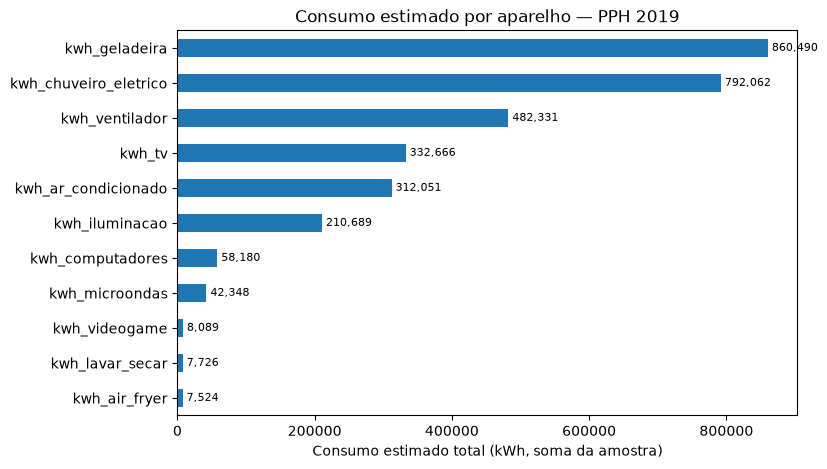

In [20]:
ax = total_por_aparelho.sort_values().plot(kind="barh", figsize=(8, 5))
ax.set_xlabel("Consumo estimado total (kWh, soma da amostra)")
ax.set_title("Consumo estimado por aparelho — PPH 2019")
for i, v in enumerate(total_por_aparelho.sort_values()):
    ax.text(v, i, f" {v:,.0f}", va="center", fontsize=8)


## 8. Exportação dos arquivos `.csv`

Três arquivos são gerados:

1. **`consumo_energetico_completo.csv`** — tabela completa (todas as
   colunas construídas nas seções anteriores).
2. **`consumo_top3_aparelhos.csv`** — apenas identificação + quantidade e
   consumo dos **3 aparelhos que mais consumiram energia**.
3. **`consumo_categoria_top.csv`** — apenas identificação + quantidade e
   consumo dos aparelhos pertencentes à **categoria que mais consumiu
   energia**.


In [21]:
from pathlib import Path

OUT_DIR = Path("output")
OUT_DIR.mkdir(exist_ok=True)

# 1) Tabela completa
df_final.to_csv(OUT_DIR / "consumo_energetico_completo.csv", index=False, encoding="utf-8-sig")

# 2) Apenas os 3 aparelhos que mais consumiram energia
sufixo_top3 = [c.replace("kwh_", "") for c in top3_aparelhos.index]
colunas_top3 = ["ENTREVISTA", "REGIAO", "UF", "MUNICIPIO"]
for suf in sufixo_top3:
    colunas_top3 += [c for c in (f"qtd_{suf}", f"kwh_{suf}") if c in df_final.columns]
df_final[colunas_top3].to_csv(OUT_DIR / "consumo_top3_aparelhos.csv", index=False, encoding="utf-8-sig")

# 3) Apenas a categoria que mais consumiu energia
nome_categoria_top = [k for k in CATEGORIAS if f"kwh_categoria_{k.lower()}" == categoria_top][0]
cols_categoria_top = CATEGORIAS[nome_categoria_top]
colunas_cat_top = ["ENTREVISTA", "REGIAO", "UF", "MUNICIPIO"]
for c in cols_categoria_top:
    suf = c.replace("kwh_", "")
    colunas_cat_top += [x for x in (f"qtd_{suf}", f"kwh_{suf}") if x in df_final.columns]
colunas_cat_top.append(categoria_top)
df_final[colunas_cat_top].to_csv(OUT_DIR / "consumo_categoria_top.csv", index=False, encoding="utf-8-sig")

print("Arquivos gerados em:", OUT_DIR.resolve())
for f in sorted(OUT_DIR.glob("*.csv")):
    print(" -", f.name)


Arquivos gerados em: C:\Users\Usuario\Desktop\PROCESSAMENTO DE DADOS PPH\output
 - consumo_categoria_top.csv
 - consumo_energetico_completo.csv
 - consumo_top3_aparelhos.csv


## 9. Conclusão e próximos passos

- A tabela `consumo_energetico_completo.csv` já está pronta para qualquer
  análise posterior (estatística descritiva, modelos, segmentação por
  região etc.).
- Se você tiver acesso a **potências reais** de algum dos aparelhos
  assumidos (Seção 3.4), é só ajustar a constante correspondente e rodar o
  notebook novamente — o restante do pipeline não precisa mudar.
- Vale conferir os **outliers** de consumo (ex. valores muito altos de
  `kwh_chuveiro_eletrico`) antes de usar os dados em um modelo, pois eles
  podem refletir respostas extremas legítimas ou erros de preenchimento na
  pesquisa original.
